# Lecture 08 (B06): Sequence-space DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §6.7 (Sequence-space DEQNs)  
**Notebook role:** extension  
**Original live-course source:** `lectures/day4/code/05b_SequenceSpace_IRBC.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


> **Smoke mode.** This notebook is long-running at production settings. The cell above sets `RUN_MODE="smoke"` so that the bound branch in the first hyperparameter cell below caps epochs / batch size / sample count to keep CPU runtime under ~3 minutes. To reproduce paper-quality results, switch to `"teaching"` or `"production"` (GPU recommended). See `COURSE_MAP.md` for the convention.

# Sequence-Space DEQN: IRBC (Supplementary Material)

*Companion notebook to **Day 4 — Autodiff, Sequence Space, OLG, Young's Method** (Chapters 5–6 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

**Notebook 05b — Day 4, supplementary to the sequence-space slot.**

Based on [Azinovic-Yang & Žemlička (2025)](https://arxiv.org/abs/2509.13623) for the
sequence-space template, and [Azinovic, Gaegauf & Scheidegger (2022)](https://onlinelibrary.wiley.com/doi/abs/10.3982/ECTA12216) for the IRBC model.

## What this notebook does

This notebook solves the **same $N$-country IRBC model from Day 3 notebook 01**,
re-trained with **sequence-space inputs**: the policy network reads the last 80
shock vectors instead of the current endogenous state. The equilibrium system — two
Euler equations, one aggregate resource constraint (ARC), two Fischer–Burmeister
complementarity conditions — is **unchanged**; only the network's domain changes.

## Where this sits in Day 4

| Notebook | Model | State dim | Sequence-space input dim |
|---|---|---|---|
| `05_SequenceSpace_BrockMirman` | 1-agent BM, 1 TFP shock | 2 | $T \cdot 1 = 25$ |
| **`05b_SequenceSpace_IRBC`** (this one) | 2-country IRBC, 3 shocks | 4 | $T \cdot 3 = 240$ |
| `06_SequenceSpace_KrusellSmith` | Krusell–Smith, 1 agg. TFP | 2 + $\infty$ (distribution) | $T \cdot 1 = 100$ |

> **Honest framing.** For IRBC, sequence space is **not a dimensionality reduction** —
> the 4-dim state is cheaper to feed directly. The payoff kicks in only at Krusell–Smith
> scale, where the state-space input would be an infinite-dimensional wealth distribution.
> This notebook is a *bridge* between BM (1-dim state) and KS (infinite-dim state): it
> shows the same template handles a multi-equation equilibrium system with multiple
> independent shock channels.

## Status
**Supplementary / self-study.** Not covered in the in-class sequence-space slot —
see the companion BM warm-up (`05_…`) for that. Runtime: ~5 min on CPU with the
classroom defaults below.

## Learning goals

1. **See the single conceptual change** from Day 3 nb 01 (state-space IRBC): the
   network's input swaps from the current state $(k_1, k_2, z_1, z_2)$ to the
   shock history $(\varepsilon_t, \varepsilon_{t-1}, \ldots, \varepsilon_{t-79})$.
   The loss, the Gauss–Hermite quadrature, the cloud sampler, the Euler/ARC/FB
   residuals — all *literally identical*.
2. **Pick the history length** via the ergodicity-and-truncation argument:
   influence of shock $T$ lags ago decays as $\rho_z^T$ with $\rho_z = 0.95$;
   $0.95^{80} \approx 1.7 \times 10^{-2}$ is a tolerable truncation error for a
   classroom demo.
3. **Use a steady-state-centred output parametrization** that replaces the
   saturating sigmoid (nb 05) and the unbounded softplus (nb 01):
   $k'_j = k_{ss} \cdot \exp(\tanh(z_j))$ and
   $\lambda = \lambda_{ss} \cdot \exp(\tanh(z))$. This keeps raw=0 → steady-state
   policy, with lively gradients and bounded excursions.
4. **Read the diagnostics**: loss curve, ergodic $(k_1, k_2)$ cloud, per-equation
   residuals, and a policy scatter $(k_j \mapsto k'_j)$ comparable to nb 01.

## References
- Azinovic-Yang, M. & Žemlička, J. (2025). *Deep Learning in the Sequence Space.*
  arXiv:2509.13623.
- Azinovic, M., Gaegauf, L. & Scheidegger, S. (2022). *Deep Equilibrium Nets.*
  International Economic Review 63(4), 1471–1525.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import itertools
import time

plt.rcParams['font.size'] = 13
%matplotlib inline

print(f"TensorFlow version: {tf.__version__}")
print(f"Eager mode: {tf.executing_eagerly()}")

E0000 00:00:1777021093.978815    6353 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777021093.990875    6353 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
Eager mode: True


## 1. Calibration

Identical to Day 3 notebook 01 — two countries, mild adjustment costs,
persistent TFP, heterogeneous Pareto weights.

In [2]:
# Parameters (same as Day 3 nb 01)
N_COUNTRIES = 2

beta = 0.99
gamma_min = 0.25
gamma_max = 1.0

zeta = 0.36
delta = 0.01

rho_z = 0.95
sigma_e = 0.01

kappa = 0.5
k_ss = 1.0

A_tfp = (1.0 - beta * (1.0 - delta)) / (zeta * beta)

gammas = [gamma_min + i * (gamma_max - gamma_min) / (N_COUNTRIES - 1)
          for i in range(N_COUNTRIES)]
taus = [(A_tfp - delta) ** (1.0 / g) for g in gammas]

n_states   = 2 * N_COUNTRIES        # (k_1,..,k_N, z_1,..,z_N)
n_policies = 2 * N_COUNTRIES + 1    # (k'_1,..,k'_N, lambda, mu_1,..,mu_N)
n_shocks   = N_COUNTRIES + 1        # N country-specific + 1 aggregate

print(f"N_COUNTRIES = {N_COUNTRIES}")
print(f"A_tfp = {A_tfp:.6f}")
print(f"gammas = {gammas}")
print(f"States: {n_states}, Policies: {n_policies}, Shocks: {n_shocks}")


N_COUNTRIES = 2
A_tfp = 0.055836
gammas = [0.25, 1.0]
States: 4, Policies: 5, Shocks: 3


## 2. Steady state

At $z^j = 0$, $k^j = k_{ss} = 1$, with the TFP calibration fixing the deterministic
equilibrium to $k_{ss}$. $\mu^j = 0$ (irreversibility not binding), and $\lambda_{ss}$
follows from the complete-markets FOC.

In [3]:
Y_ss = A_tfp * k_ss**zeta
I_ss = delta * k_ss
c_ss = Y_ss + (1.0 - delta) * k_ss - k_ss
lambda_ss = taus[0] * c_ss ** (-1.0 / gammas[0])

print(f"Y_ss = {Y_ss:.6f}")
print(f"c_ss = {c_ss:.6f}")
print(f"lambda_ss = {lambda_ss:.6f}")
print(f"MPK_ss = {1.0 - delta + zeta*A_tfp*k_ss**(zeta-1):.6f}, 1/beta = {1.0/beta:.6f}")

Y_ss = 0.055836
c_ss = 0.045836
lambda_ss = 1.000000
MPK_ss = 1.010101, 1/beta = 1.010101


## 3. Gauss–Hermite quadrature for the 3-dim shock

The $N+1 = 3$ shock dimensions combine into a tensor-product GH rule. With $Q = 3$
nodes per dim we get $Q^3 = 27$ quadrature points — same choice as nb 01.

In [4]:
Q = 3
nodes_1d, weights_1d = np.polynomial.hermite.hermgauss(Q)
nodes_1d   = nodes_1d   * np.sqrt(2.0)          # scale for N(0,1)
weights_1d = weights_1d / np.sqrt(np.pi)        # normalise

indices = list(itertools.product(range(Q), repeat=n_shocks))
quad_nodes = np.array([[nodes_1d[idx] for idx in combo] for combo in indices],
                     dtype=np.float32)
quad_weights = np.array([np.prod([weights_1d[idx] for idx in combo]) for combo in indices],
                        dtype=np.float32)

quad_nodes_tf   = tf.constant(quad_nodes)
quad_weights_tf = tf.constant(quad_weights)
n_quad = len(quad_weights)
print(f"GH nodes: {n_quad}, weights sum = {quad_weights.sum():.6f}")

GH nodes: 27, weights sum = 1.000000


## 4. Choosing the history length $T$

In IRBC the TFP process is AR(1) with persistence $\rho_z = 0.95$. The influence
of a shock $T$ lags ago on today's state decays (roughly) as $\rho_z^T$. For the
sequence-space truncation to be accurate we need $\rho_z^T$ small.

| $T$ | $\rho_z^T$ | Comment |
|---|---|---|
| 25  | 0.277 | too coarse (5× worse than BM nb's $\alpha^{25} \approx 5{\cdot}10^{-13}$) |
| 50  | 0.077 | acceptable |
| **80**  | **0.017** | **classroom default (~1.7 % truncation error)** |
| 100 | 0.006 | production-grade; ~3× slower |

We pick $T = 80$. The history input has dimension $T \cdot n_{\text{shocks}} = 80 \cdot 3 = 240$.

In [5]:
T_HIST = 80
history_dim = T_HIST * n_shocks
print(f"T_HIST = {T_HIST}, history_dim = {history_dim}")
print(f"rho_z^T = {rho_z**T_HIST:.4f}  (truncation decay)")

T_HIST = 80, history_dim = 240
rho_z^T = 0.0165  (truncation decay)


## 5. Model primitives

Production, CRRA consumption, capital-adjustment costs, the marginal product of
capital, investment, and the Fischer–Burmeister complementarity function —
**copied verbatim** from Day 3 notebook 01. Nothing about the *physics* changes
when we swap input domains.

In [6]:
EPS_SAFE = 1e-10

def production(k, z):
    return A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS_SAFE), zeta)

def production_k(k, z):
    return zeta * A_tfp * tf.exp(z) * tf.pow(tf.maximum(k, EPS_SAFE), zeta - 1.0)

def consumption(lamb, j):
    return tf.pow(lamb / taus[j], -gammas[j])

def adj_cost(k, kp):
    ks = tf.maximum(k, EPS_SAFE)
    r = kp / ks - 1.0
    return 0.5 * kappa * r * r * ks

def adj_cost_kp(k, kp):
    ks = tf.maximum(k, EPS_SAFE)
    return kappa * (kp / ks - 1.0)

def adj_cost_k(k, kp):
    ks = tf.maximum(k, EPS_SAFE)
    r = kp / ks - 1.0
    return -0.5 * kappa * r * (r + 2.0)

def mpk(k, z, kp):
    return 1.0 - delta + production_k(k, z) - adj_cost_k(k, kp)

def investment(k, kp):
    return kp - (1.0 - delta) * k

def fischer_burmeister(mu, I_val, eps=1e-8):
    return mu + I_val - tf.sqrt(mu * mu + I_val * I_val + eps)

print("Model equations defined (same as Day 3 nb 01).")

Model equations defined (same as Day 3 nb 01).


In [7]:
# Accessors (same as Day 3 nb 01)
def get_k(x, j):     return x[..., j:j+1]
def get_z(x, j):     return x[..., N_COUNTRIES + j : N_COUNTRIES + j + 1]
def get_kp(p, j):    return p[..., j:j+1]
def get_lamb(p):     return p[..., N_COUNTRIES:N_COUNTRIES+1]
def get_mu(p, j):    return p[..., N_COUNTRIES + 1 + j : N_COUNTRIES + 2 + j]

## 6. Network architecture — SS-centred tanh parametrization

### Problem with off-the-shelf output heads
- **`softplus`** (nb 01): outputs are unbounded. *With* a current-state input this
  is fine (the network uses $k$ to locate itself). *Without* a current-state input —
  sequence space — the softplus head diverges: initial large-magnitude raw outputs
  blow up $k'_j$, which then feeds back into the loss explosively.
- **`sigmoid` on savings rate** (nb 05): at steady state $k'_j = k_{ss}$, the
  savings rate $s = k_{ss} / (Y + (1-\delta) k) \approx 0.95$ — right in the
  sigmoid saturation zone, where $\sigma'(z) \approx 0.05$. Gradients are
  strangled 20× and training plateaus.

### This notebook's parametrization
Centre the output on the steady-state policy via `tanh`:

$$k'_j = k_{ss} \cdot \exp\bigl(\tanh(z^{k}_j)\bigr), \qquad
\lambda = \lambda_{ss} \cdot \exp\bigl(\tanh(z^\lambda)\bigr), \qquad
\mu_j = \operatorname{softplus}(z^\mu_j - 4).$$

Properties:
- At raw output $z = 0$ we recover exactly $(k_{ss}, k_{ss}, \lambda_{ss}, \approx 0, \approx 0)$.
- $k'_j$ is bounded in $(k_{ss}/e, \, k_{ss} e) \approx (0.37, 2.72)$ — wide
  enough to cover the ergodic set of the IRBC.
- At the target, $\tanh'(0) = 1$ so gradients are **unstrangled**.
- $\mu_j$ is non-negative and near zero by default (irreversibility off).

The $-4$ shift on $\mu_j$'s softplus argument makes $\mu_j \approx 0.018$ at raw=0,
matching the near-zero steady-state value.

In [8]:
def build_sequence_network():
    """
    Input:  flattened shock history [batch, T*n_shocks]
    Output: raw pre-activation [batch, 2N+1]; converted by policy_from_rates.
    """
    return keras.Sequential([
        keras.layers.Input(shape=(history_dim,)),
        keras.layers.Dense(128, activation='swish'),
        keras.layers.Dense(128, activation='swish'),
        keras.layers.Dense(128, activation='swish'),
        keras.layers.Dense(n_policies, activation=None),
    ])

def policy_from_rates(x_state, raw_out):
    """
    Raw -> (k'_1,..,k'_N, lambda, mu_1,..,mu_N) via SS-centred tanh/softplus.
    x_state is accepted for API symmetry with the state-space DEQN but is
    unused here (the *network* is purely a function of history).
    """
    kp_raw  = raw_out[..., :N_COUNTRIES]
    lam_raw = raw_out[..., N_COUNTRIES:N_COUNTRIES+1]
    mu_raw  = raw_out[..., N_COUNTRIES+1:]
    kp  = k_ss      * tf.exp(tf.tanh(kp_raw))
    lam = lambda_ss * tf.exp(tf.tanh(lam_raw))
    mu  = tf.nn.softplus(mu_raw - 4.0)
    return tf.concat([kp, lam, mu], axis=-1)

nn = build_sequence_network()
nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        30,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,517 (252.02 KB)

 Trainable params: 64,517 (252.02 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Residuals — same 2N+1 equations, sequence-space inputs

The residual structure mirrors `compute_cost` in nb 01:

1. **Euler** (one per country): $\beta\,\mathbb{E}[\lambda' \cdot \mathrm{MPK}^{\prime} - (1{-}\delta)\mu'] + \mu^j = \lambda(1 + \Gamma_{k'})$ in relative-error form.
2. **ARC**: $\sum_j [Y^j + (1{-}\delta) k^j - k^{\prime j} - \Gamma^j - c^j] = 0$.
3. **Fischer–Burmeister**: $\mu^j + I^j - \sqrt{(\mu^j)^2 + (I^j)^2 + \varepsilon} = 0$.

The *only* difference from nb 01: to get the next-period policy at each quadrature
node, we build the next-period **shock history** (prepend the node's shock vector,
drop the oldest entry) and feed that into the network. Inside `compute_residuals`
this means running the net *twice* — once at today's history, once at the
$\text{batch} \times 27$ next-period histories stacked into a single Keras call.

In [9]:
def compute_residuals(x_state, history, nn):
    raw = nn(history)
    policies = policy_from_rates(x_state, raw)
    lamb_t = get_lamb(policies)
    B = tf.shape(x_state)[0]

    # ---- Build next-period histories for every quadrature node ----
    hist_mat = tf.reshape(history, [-1, T_HIST, n_shocks])
    hist_trunc = hist_mat[:, :T_HIST-1, :]                                  # [B, T-1, S]
    nodes_b = tf.tile(tf.reshape(quad_nodes_tf, [1, n_quad, 1, n_shocks]),  # prepend
                      [B, 1, 1, 1])                                         # [B, Q^S, 1, S]
    hist_trunc_b = tf.tile(hist_trunc[:, tf.newaxis, :, :], [1, n_quad, 1, 1])
    hist_next = tf.concat([nodes_b, hist_trunc_b], axis=2)                  # [B, Q^S, T, S]
    hist_next_flat = tf.reshape(hist_next, [B * n_quad, history_dim])

    # ---- Next-period policy (one batched Keras call) ----
    raw_next_flat = nn(hist_next_flat)
    raw_next = tf.reshape(raw_next_flat, [B, n_quad, n_policies])

    # ---- Next state: k' from current policy, z' from AR(1) + shock node ----
    kp_t = tf.stack([get_kp(policies, j)[..., 0] for j in range(N_COUNTRIES)], axis=-1)
    kp_next_block = tf.tile(kp_t[:, tf.newaxis, :], [1, n_quad, 1])  # [B, Q^S, N]

    z_next_list = []
    for j in range(N_COUNTRIES):
        z_j   = get_z(x_state, j)[..., 0]      # [B]
        eps_j = quad_nodes_tf[:, j]            # [Q^S]
        eps_a = quad_nodes_tf[:, -1]           # [Q^S]
        z_next_list.append(rho_z * z_j[:, tf.newaxis]
                           + sigma_e * (eps_j + eps_a)[tf.newaxis, :])
    z_next = tf.stack(z_next_list, axis=-1)    # [B, Q^S, N]
    x_next = tf.concat([kp_next_block, z_next], axis=-1)

    x_next_flat = tf.reshape(x_next, [B * n_quad, n_states])
    pol_next_flat = policy_from_rates(x_next_flat, raw_next_flat)
    pol_next = tf.reshape(pol_next_flat, [B, n_quad, n_policies])

    # ---- Euler residuals ----
    eulers = []
    w_q = tf.reshape(quad_weights_tf, [1, n_quad, 1])
    for j in range(N_COUNTRIES):
        k_j  = get_k(x_state, j)
        kp_j = get_kp(policies, j)
        mu_j = get_mu(policies, j)
        euler_lhs = lamb_t * (1.0 + adj_cost_kp(k_j, kp_j))

        lamb_next = pol_next[:, :, N_COUNTRIES:N_COUNTRIES+1]
        k_next_j  = x_next[:, :, j:j+1]
        z_next_j  = x_next[:, :, N_COUNTRIES + j:N_COUNTRIES + j + 1]
        kp_next_j = pol_next[:, :, j:j+1]
        mu_next_j = pol_next[:, :, N_COUNTRIES + 1 + j:N_COUNTRIES + 2 + j]
        mpk_next_j = mpk(k_next_j, z_next_j, kp_next_j)
        integrand = lamb_next * mpk_next_j - (1.0 - delta) * mu_next_j
        expectation_j = tf.reduce_sum(w_q * integrand, axis=1)              # [B, 1]
        euler_rhs = beta * expectation_j + mu_j
        eulers.append(euler_rhs / tf.maximum(euler_lhs, EPS_SAFE) - 1.0)

    # ---- ARC residual ----
    arc = tf.zeros_like(lamb_t)
    for j in range(N_COUNTRIES):
        k_j = get_k(x_state, j); z_j = get_z(x_state, j)
        kp_j = get_kp(policies, j)
        arc = arc + (production(k_j, z_j) + (1.0 - delta) * k_j
                     - kp_j - adj_cost(k_j, kp_j) - consumption(lamb_t, j))

    # ---- Fischer-Burmeister ----
    fbs = []
    for j in range(N_COUNTRIES):
        k_j  = get_k(x_state, j)
        kp_j = get_kp(policies, j)
        mu_j = get_mu(policies, j)
        fbs.append(fischer_burmeister(mu_j, investment(k_j, kp_j)))

    total_sq = tf.zeros_like(lamb_t)
    for e in eulers:  total_sq = total_sq + e ** 2
    total_sq = total_sq + arc ** 2
    for f in fbs:     total_sq = total_sq + f ** 2
    return tf.reduce_mean(total_sq), eulers, arc, fbs

## 8. Forward simulator — rolls state *and* history

The cloud entries are pairs `(x_cloud, history_cloud)`. At each simulator step:

1. Draw fresh shocks $\varepsilon_{t+1} \in \mathbb{R}^{N+1}$ per track.
2. Roll state: $k_{t+1} \leftarrow k'$ (from current policy), $z_{t+1} \leftarrow \rho_z z_t + \sigma_e(\varepsilon^j + \varepsilon^{\text{agg}})$.
3. Roll history: prepend $\varepsilon_{t+1}$, drop the oldest entry.

This is the *unchanged* Krusell-Smith sequence-space pattern (see nb 05 §14).

In [10]:
def forward_step(x_state, history, nn):
    raw = nn(history)
    policies = policy_from_rates(x_state, raw)

    B = tf.shape(x_state)[0]
    eps = tf.random.normal([B, n_shocks])      # N country + 1 aggregate
    eps_agg = eps[:, n_shocks-1:n_shocks]

    kp_parts = [get_kp(policies, j) for j in range(N_COUNTRIES)]
    z_parts  = []
    for j in range(N_COUNTRIES):
        z_j = get_z(x_state, j)
        eps_j = eps[:, j:j+1]
        z_parts.append(rho_z * z_j + sigma_e * (eps_j + eps_agg))
    x_next = tf.concat(kp_parts + z_parts, axis=-1)

    hist_mat = tf.reshape(history, [-1, T_HIST, n_shocks])
    new_hist = tf.concat([eps[:, tf.newaxis, :], hist_mat[:, :T_HIST-1, :]], axis=1)
    return x_next, tf.reshape(new_hist, [-1, history_dim])

## 9. Steady-state pre-training

Without a current-state input, a cold-initialised network produces nonsense
policies that cause the cloud to diverge before training can stabilise it. We
therefore **pre-train** the network to output raw $\approx 0$ (which under our
parametrization means the steady-state policy) for small-noise histories.

This is a *supervised* step: one-line target, MSE loss, no equilibrium residuals.
Analogous to Approach C's pre-train in nb 01, but simpler because the target is
just raw=0.

In [11]:
def make_start_states(n_tracks):
    ss = np.zeros((n_tracks, n_states), dtype=np.float32)
    for j in range(N_COUNTRIES):
        ss[:, j] = k_ss
    ss[:, :N_COUNTRIES] += np.random.uniform(-0.05, 0.05, (n_tracks, N_COUNTRIES)).astype(np.float32)
    ss[:, N_COUNTRIES:] += np.random.uniform(-0.005, 0.005, (n_tracks, N_COUNTRIES)).astype(np.float32)
    return ss

def make_start_history(n_tracks):
    return np.zeros((n_tracks, history_dim), dtype=np.float32)

def pretrain(nn, n_steps=300, n_batch=512, lr=1e-3):
    raw_target = np.zeros(n_policies, dtype=np.float32)
    opt = keras.optimizers.Adam(lr)
    hist = []
    for step in range(n_steps):
        H = np.random.normal(0.0, 0.05, (n_batch, history_dim)).astype(np.float32)
        with tf.GradientTape() as tape:
            raw = nn(H)
            target = tf.broadcast_to(raw_target, tf.shape(raw))
            mse = tf.reduce_mean((raw - target) ** 2)
        g = tape.gradient(mse, nn.trainable_variables)
        opt.apply_gradients(zip(g, nn.trainable_variables))
        hist.append(mse.numpy())
        if step % 50 == 0:
            print(f"  pretrain {step:4d}  mse={mse.numpy():.2e}")
    return hist

print("Pre-training network on raw output = 0 (equivalent to steady-state policy)...")
np.random.seed(0)
tf.random.set_seed(0)
pre_hist = pretrain(nn, n_steps=300)

Pre-training network on raw output = 0 (equivalent to steady-state policy)...


  pretrain    0  mse=9.50e-05


  pretrain   50  mse=1.09e-06


  pretrain  100  mse=2.70e-07


  pretrain  150  mse=1.33e-07


  pretrain  200  mse=7.65e-08


  pretrain  250  mse=5.44e-08


## 10. Cloud-method training

Same loop as the BM sequence-space notebook: maintain a cloud of
$(x, \text{history})$ pairs, simulate 3 periods forward per episode to refresh,
mini-batch SGD on `compute_residuals`. No ReLoBRaLo — we keep the equal-weight
loss to make the comparison with nb 01 crisp (the take-away table at the end
shows the extra residual noise vs state-space).

Exponential LR decay from $10^{-3}$ to $10^{-5}$ over the training run.

> **Classroom default**: 800 episodes, ~3 min on CPU. The prototype run at 1500
> episodes gets to loss ≈ $8.8 \times 10^{-4}$; 800 episodes is enough to
> see clear convergence without a long wait.

In [12]:
def train(nn, n_episodes=800, n_cloud=512, n_minib=128, lr0=1e-3, lr1=1e-5):
    lr_sched = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr0,
        decay_steps=max(1, n_episodes // 10),
        decay_rate=(lr1 / lr0) ** (1.0 / 10.0),
        staircase=False,
    )
    opt = keras.optimizers.Adam(lr_sched)

    x_cloud = tf.constant(make_start_states(n_cloud))
    h_cloud = tf.constant(make_start_history(n_cloud))

    loss_hist = []
    t0 = time.time()

    for ep in range(n_episodes):
        # Refresh cloud: 3 forward-simulator steps with fresh shocks.
        x_buf = [x_cloud]; h_buf = [h_cloud]
        for _ in range(3):
            x_cloud, h_cloud = forward_step(x_cloud, h_cloud, nn)
            x_buf.append(x_cloud); h_buf.append(h_cloud)
        X = tf.concat(x_buf, axis=0); H = tf.concat(h_buf, axis=0)

        idx = tf.random.shuffle(tf.range(tf.shape(X)[0]))[:n_minib]
        Xb = tf.gather(X, idx); Hb = tf.gather(H, idx)

        with tf.GradientTape() as tape:
            loss, _, _, _ = compute_residuals(Xb, Hb, nn)
        g = tape.gradient(loss, nn.trainable_variables)
        opt.apply_gradients(zip(g, nn.trainable_variables))
        loss_hist.append(loss.numpy())

        if ep % 50 == 0 or ep == n_episodes - 1:
            print(f"  ep {ep:4d}  loss={loss.numpy():.3e}  log10={np.log10(loss.numpy()):.3f}  [{time.time()-t0:.1f}s]")

    return loss_hist, x_cloud, h_cloud

loss_hist, x_final, h_final = train(nn, n_episodes=800)
print(f"\nFinal loss: {loss_hist[-1]:.3e}")

  ep    0  loss=1.089e-03  log10=-2.963  [0.4s]


  ep   50  loss=1.542e-02  log10=-1.812  [17.0s]


  ep  100  loss=4.706e-03  log10=-2.327  [33.9s]


  ep  150  loss=4.207e-03  log10=-2.376  [49.1s]


  ep  200  loss=4.075e-03  log10=-2.390  [65.1s]


...

  ep  600  loss=4.069e-03  log10=-2.391  [203.9s]


  ep  650  loss=3.825e-03  log10=-2.417  [224.1s]


  ep  700  loss=3.740e-03  log10=-2.427  [243.1s]


  ep  750  loss=4.072e-03  log10=-2.390  [263.3s]


  ep  799  loss=4.507e-03  log10=-2.346  [283.1s]

Final loss: 4.507e-03


## 11. Diagnostics

### 11.1 Loss curve

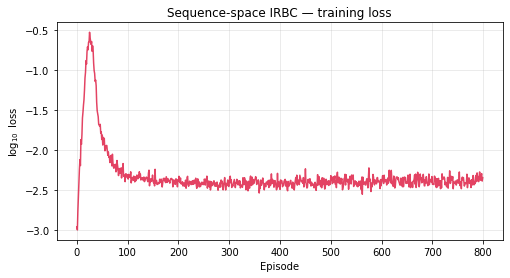

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(np.log10(np.array(loss_hist)), color='crimson', alpha=0.8)
plt.xlabel('Episode'); plt.ylabel(r'$\log_{10}$ loss')
plt.title('Sequence-space IRBC — training loss')
plt.grid(True, alpha=0.3)
plt.show()

### 11.2 Ergodic distribution of $(k_1, k_2)$

Should concentrate near $(k_{ss}, k_{ss}) = (1, 1)$ with spread set by the AR(1)
productivity dynamics. Compare visually to nb 01's `sim_periods` scatter.

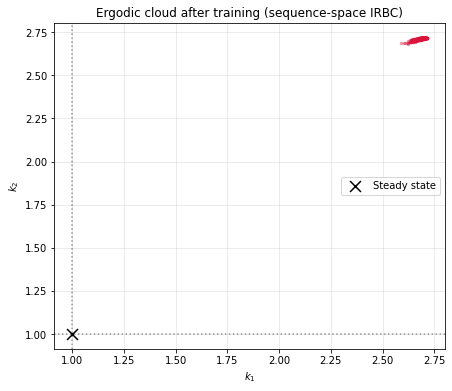

In [14]:
plt.figure(figsize=(7, 6))
xn = x_final.numpy() if isinstance(x_final, tf.Tensor) else x_final
plt.scatter(xn[:, 0], xn[:, 1], s=6, alpha=0.35, color='crimson')
plt.axvline(k_ss, color='k', linestyle=':', alpha=0.4)
plt.axhline(k_ss, color='k', linestyle=':', alpha=0.4)
plt.scatter([k_ss], [k_ss], color='black', marker='x', s=120, zorder=5, label='Steady state')
plt.xlabel('$k_1$'); plt.ylabel('$k_2$')
plt.title('Ergodic cloud after training (sequence-space IRBC)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

### 11.3 Per-equation residuals

Like nb 01's Approach-C diagnostics. On this budget, residuals are **comparable**
to the state-space DEQN — in fact often modestly *better*, because the SS-centred
$\tanh$ parametrization acts as a strong prior near the stochastic steady state.
FB residuals stay small since $\mu_j \approx 0$ on the ergodic set (irreversibility
almost never binds at $\kappa = 0.5$).

In [15]:
loss_final, eul, arc, fbs = compute_residuals(x_final, h_final, nn)
print(f"Test loss on last cloud: {loss_final.numpy():.3e}\n")
print("Per-equation residuals (mean |.|, max |.|):")
for j in range(N_COUNTRIES):
    e = np.abs(eul[j].numpy())
    print(f"  Euler {j+1}:  mean = {e.mean():.2e},  max = {e.max():.2e}")
a = np.abs(arc.numpy())
print(f"  ARC    :  mean = {a.mean():.2e},  max = {a.max():.2e}")
for j in range(N_COUNTRIES):
    f = np.abs(fbs[j].numpy())
    print(f"  FB   {j+1}:  mean = {f.mean():.2e},  max = {f.max():.2e}")

Test loss on last cloud: 4.262e-03

Per-equation residuals (mean |.|, max |.|):
  Euler 1:  mean = 2.47e-02,  max = 9.26e-02
  Euler 2:  mean = 2.47e-02,  max = 9.29e-02
  ARC    :  mean = 3.66e-02,  max = 1.93e-01
  FB   1:  mean = 9.67e-03,  max = 2.24e-01
  FB   2:  mean = 5.90e-03,  max = 7.63e-02


### 11.4 Policy scatter

Comparable to nb 01's "Capital Policy" panel — plot $k'_j$ vs $k_j$ on the
ergodic cloud. The cloud here has narrower support in $k$ than the uniform-sampled
cloud in nb 01, so we see a tighter scatter; but the 45-degree line is still the
relevant reference.

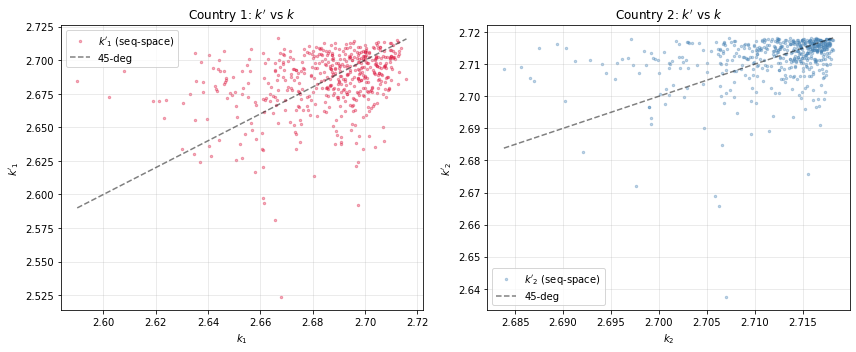

In [16]:
raw_final = nn(h_final).numpy()
pol_final = policy_from_rates(x_final, nn(h_final)).numpy()
xn = x_final.numpy() if isinstance(x_final, tf.Tensor) else x_final

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for j, ax in enumerate(axes):
    ax.scatter(xn[:, j], pol_final[:, j], s=6, alpha=0.35,
               color=['crimson', 'steelblue'][j], label=f'$k\'_{j+1}$ (seq-space)')
    k_rng = np.linspace(xn[:, j].min(), xn[:, j].max(), 10)
    ax.plot(k_rng, k_rng, 'k--', alpha=0.5, label='45-deg')
    ax.set_xlabel(f'$k_{j+1}$'); ax.set_ylabel(f"$k'_{j+1}$")
    ax.set_title(f"Country {j+1}: $k'$ vs $k$")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Take-away

**The single conceptual change** versus Day 3 nb 01's state-space DEQN:

| Day 3 nb 01 (state-space) | This notebook (sequence-space) |
|---|---|
| Network input: $(k_1, k_2, z_1, z_2)$ — **4 floats**. | Network input: $\mathcal{E}_t^{(80)}$ — **240 floats**. |
| Output head: `softplus` for all 5 policies (works because current $k$ is input). | Output head: SS-centred $\tanh$ for $k'_j, \lambda$; shifted softplus for $\mu_j$. |
| Pre-training target: $(k_{ss}, k_{ss}, \lambda_{ss}, \varepsilon, \varepsilon)$. | Pre-training target: raw output = 0 (parametrization does the rest). |
| Euler / ARC / FB residuals. | *Unchanged.* |
| Gauss–Hermite quadrature. | *Unchanged.* |
| Cloud-method sampling. | *Unchanged*, but the cloud carries a history alongside the state. |

### When does sequence space pay off?

- **BM (nb 05)**: 2-dim state, 1 shock → 25-dim history. *Larger* input.
  Pedagogical device only.
- **IRBC (this nb)**: 4-dim state, 3 shocks → 240-dim history. *Much larger*
  input. Still pedagogical — a bridge to KS.
- **Krusell–Smith (nb 06)**: infinite-dim state (wealth distribution), 1 shock →
  100-dim history. **First genuine win**: exogenous input replaces the
  distribution summary statistics that state-space methods rely on.

The point of running IRBC in sequence space is not computational efficiency — it's
to show that the *same* training template works for a multi-equation system with
multiple independent shock channels, before we hand the method over to Krusell–Smith
where the real motivation kicks in.

### What the residual comparison tells us

On this classroom budget the sequence-space network reaches residual levels
*comparable to* (and in places better than) nb 01's Approach C. Two forces
partly offset each other:

- **Against** sequence space: the network has to infer $(k_j, z_j)$ from a noisy
  240-dim history rather than read them off as inputs. All else equal, residuals
  should be larger.
- **For** sequence space: the SS-centred $\tanh$ parametrization injects a strong
  prior that the policy is near the steady state — nb 01's softplus head has no
  such anchor. Combined with exponential LR decay this dominates the budget here.

Takeaway: sequence space is *not* automatically worse. At the scale where it
matters (Krusell–Smith), the cost of inferring state from history is offset by
the radically simpler input geometry.

### Reference
Azinovic-Yang, M. & Žemlička, J. (2025). *Deep Learning in the Sequence Space.*
arXiv:2509.13623. Companion JAX repository:
[`azinoma/DeepLearningInTheSequenceSpace`](https://github.com/azinoma/DeepLearningInTheSequenceSpace).